In [33]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error,confusion_matrix,classification_report
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler



In [30]:
df = pd.read_csv('set_for_classification.csv')  

In [31]:
print(df.head())

   ID  Default  Prct_uso_tc  Edad  Nro_prestao_retrasados  \
0   1        1     0.766127    45                       2   
1   2        0     0.957151    40                       0   
2   3        0     0.658180    38                       1   
3   4        0     0.233810    30                       0   
4   5        0     0.907239    49                       1   

   Prct_deuda_vs_ingresos  Mto_ingreso_mensual  Nro_prod_financieros_deuda  \
0                0.802982               9120.0                          13   
1                0.121876               2600.0                           4   
2                0.085113               3042.0                           2   
3                0.036050               3300.0                           5   
4                0.024926              63588.0                           7   

   Nro_retraso_60dias  Nro_creditos_hipotecarios  Nro_retraso_ultm3anios  \
0                   0                          6                       0   
1           

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          150000 non-null  int64  
 1   Default                     150000 non-null  int64  
 2   Prct_uso_tc                 150000 non-null  float64
 3   Edad                        150000 non-null  int64  
 4   Nro_prestao_retrasados      150000 non-null  int64  
 5   Prct_deuda_vs_ingresos      150000 non-null  float64
 6   Mto_ingreso_mensual         120269 non-null  float64
 7   Nro_prod_financieros_deuda  150000 non-null  int64  
 8   Nro_retraso_60dias          150000 non-null  int64  
 9   Nro_creditos_hipotecarios   150000 non-null  int64  
 10  Nro_retraso_ultm3anios      150000 non-null  int64  
 11  Nro_dependiente             146076 non-null  float64
dtypes: float64(4), int64(8)
memory usage: 13.7 MB
None


In [5]:
print(df.describe())

                  ID        Default    Prct_uso_tc           Edad  \
count  150000.000000  150000.000000  150000.000000  150000.000000   
mean    75000.500000       0.066840       6.048438      52.295207   
std     43301.414527       0.249746     249.755371      14.771866   
min         1.000000       0.000000       0.000000       0.000000   
25%     37500.750000       0.000000       0.029867      41.000000   
50%     75000.500000       0.000000       0.154181      52.000000   
75%    112500.250000       0.000000       0.559046      63.000000   
max    150000.000000       1.000000   50708.000000     109.000000   

       Nro_prestao_retrasados  Prct_deuda_vs_ingresos  Mto_ingreso_mensual  \
count           150000.000000           150000.000000         1.202690e+05   
mean                 0.421033              353.005076         6.670221e+03   
std                  4.192781             2037.818523         1.438467e+04   
min                  0.000000                0.000000         0.00

In [6]:
df = df.dropna()

In [7]:
X = df.drop(['ID','Default'], axis=1)

In [8]:
y = df['Default']

In [9]:
print("Shape of dataset:", X.shape)

Shape of dataset: (120269, 10)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(f"Training set size: {X_train.shape}")

Training set size: (96215, 10)


In [12]:
print(f"Testing set size: {X_test.shape}")

Testing set size: (24054, 10)


In [13]:
# ====================================================================================================================
# Decision Tree Classifier
# Version 1

In [14]:
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

In [16]:
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 93.06%
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     22356
           1       0.53      0.15      0.23      1698

    accuracy                           0.93     24054
   macro avg       0.73      0.57      0.60     24054
weighted avg       0.91      0.93      0.91     24054

[[22135   221]
 [ 1449   249]]


In [17]:
# ====================================================================================================================
# Decision Tree Classifier
# Version 2

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.001, random_state=42)

In [19]:
clf1 = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf1.fit(X_train, y_train)
y_pred1 = clf1.predict(X_test)

In [20]:
accuracy1 = accuracy_score(y_test, y_pred1)

In [21]:
print(f"Accuracy: {accuracy1 * 100:.2f}%")
print(classification_report(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))

Accuracy: 95.87%
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       115
           1       1.00      0.17      0.29         6

    accuracy                           0.96       121
   macro avg       0.98      0.58      0.63       121
weighted avg       0.96      0.96      0.94       121

[[115   0]
 [  5   1]]


In [22]:
# ====================================================================================================================
# K Neighbours Classifier
# Version 1

In [23]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
ypred=knn.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, ypred)}%")
print(classification_report(y_test, ypred))
print(confusion_matrix(y_test, ypred))

Accuracy: 0.9504132231404959%
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       115
           1       0.00      0.00      0.00         6

    accuracy                           0.95       121
   macro avg       0.48      0.50      0.49       121
weighted avg       0.90      0.95      0.93       121

[[115   0]
 [  6   0]]


C:\Users\javoh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\javoh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\javoh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [27]:
# ====================================================================================================================
# K Neighbours Classifier
# Version 2

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

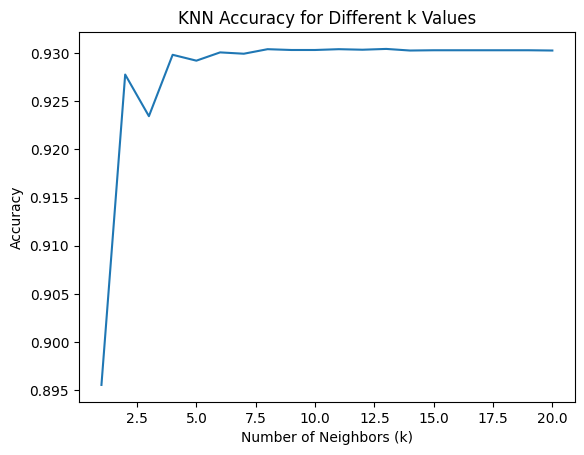

Best k: 13 with accuracy: 93.04%
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     33563
           1       0.55      0.00      0.01      2518

    accuracy                           0.93     36081
   macro avg       0.74      0.50      0.49     36081
weighted avg       0.90      0.93      0.90     36081

[[33554     9]
 [ 2507    11]]


In [29]:
# Find the best k using a loop
accuracies = []
for k in range(1, 21):  # Test k values from 1 to 20
    knn1 = KNeighborsClassifier(n_neighbors=k)
    knn1.fit(X_train, y_train)
    ypred1 = knn1.predict(X_test)
    accuracies.append(accuracy_score(y_test, ypred1))

# Plot the accuracies
import matplotlib.pyplot as plt

plt.plot(range(1, 21), accuracies)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different k Values')
plt.show()

# Print the best k
best_k = np.argmax(accuracies) + 1
print(f"Best k: {best_k} with accuracy: {max(accuracies) * 100:.2f}%")
print(classification_report(y_test, ypred1))
print(confusion_matrix(y_test, ypred1))


In [43]:
# ====================================================================================================================
# Neural Network
# Version 1

In [40]:
model = Sequential()

model.add(Dense(units=16, input_dim=X_train.shape[1], activation='relu')) 
model.add(Dense(units=8, activation='relu'))  
model.add(Dense(units=1, activation='sigmoid'))  
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [41]:

model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)
y_pred_probs = model.predict(X_test)  
y_pred = (y_pred_probs > 0.5).astype(int)   
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Epoch 1/10
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8928 - loss: 3.0865 - val_accuracy: 0.9309 - val_loss: 0.5717
Epoch 2/10
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9123 - loss: 0.6247 - val_accuracy: 0.9313 - val_loss: 1.0561
Epoch 3/10
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9107 - loss: 0.5980 - val_accuracy: 0.9313 - val_loss: 0.6999
Epoch 4/10
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9145 - loss: 0.7191 - val_accuracy: 0.9315 - val_loss: 0.8930
Epoch 5/10
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9182 - loss: 0.5744 - val_accuracy: 0.9315 - val_loss: 1.8165
Epoch 6/10
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9151 - loss: 1.2411 - val_accuracy: 0.9330 - val_loss: 0.2826
Epoch 7/10
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9160 - loss: 0.6533 - val_accuracy: 0.9322 - val_loss: 0.2852
Epoch 8/10
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9191 - loss: 0.5089 - 

In [39]:
# ====================================================================================================================
# Neural Network
# Version 2

In [42]:

model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)
y_pred_probs = model.predict(X_test)  
y_pred = (y_pred_probs > 0.5).astype(int)   
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Epoch 1/100
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9203 - loss: 0.3767 - val_accuracy: 0.9315 - val_loss: 1.3165
Epoch 2/100
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9180 - loss: 0.4639 - val_accuracy: 0.9325 - val_loss: 0.3525
Epoch 3/100
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9229 - loss: 0.4482 - val_accuracy: 0.9324 - val_loss: 0.6041
Epoch 4/100
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9251 - loss: 0.3878 - val_accuracy: 0.9332 - val_loss: 0.3003
Epoch 5/100
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9261 - loss: 0.4277 - val_accuracy: 0.9327 - val_loss: 0.3803
Epoch 6/100
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9276 - loss: 0.3252 - val_accuracy: 0.9331 - val_loss: 0.2378
Epoch 7/100
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9207 - loss: 0.4240 - val_accuracy: 0.9339 - val_loss: 0.2958
Epoch 8/100
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9257 - loss: 0